In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
metrics_dir = Path("data_for_models")
metrics_dir.mkdir(parents=True, exist_ok=True)

In [12]:
M4_MODEL_NAME = "M4_multimodal"
M2_GEO_MODEL = "M2.1.4_full"       
M2_MACRO_MODEL = "M2.2.2_full"    
M2_FULL_MODEL = "M2.3.2_full"     
M2_BASELINE_MODEL = "M2.3.0_structure"  

In [14]:
m1_cv_metrics = pd.read_csv(metrics_dir / "m1_cv_metrics.csv", encoding="utf-8-sig")
m2_cv_metrics = pd.read_csv(metrics_dir / "m2_cv_metrics.csv", encoding="utf-8-sig")
m25_cv_metrics = pd.read_csv(metrics_dir / "m2_5_cv_metrics.csv", encoding="utf-8-sig")
m210_cv_metrics = pd.read_csv(metrics_dir / "m2_10_cv_metrics.csv", encoding="utf-8-sig")
m3_cv_metrics = pd.read_csv(metrics_dir / "m3_text_cv_metrics.csv", encoding="utf-8-sig")
m4_cv_metrics = pd.read_csv(metrics_dir / "m4_cv_metrics.csv", encoding="utf-8-sig",  sep=";")
for df in (m1_cv_metrics, m2_cv_metrics, m25_cv_metrics, m210_cv_metrics, m3_cv_metrics, m4_cv_metrics):
  if "model" in df.columns:
    df.rename(columns={"model": "Model"}, inplace=True)
# --- M1
m1_part = m1_cv_metrics.loc[
  m1_cv_metrics["Model"].isin(
    ["OLS (sklearn pipeline, GroupKFold)", "Ridge (sklearn pipeline, GroupKFold)"]
  )
].copy()
m1_part["Stage"] = m1_part["Model"].map({
  "OLS (sklearn pipeline, GroupKFold)": "M1.1",
  "Ridge (sklearn pipeline, GroupKFold)": "M1.2",
})
m1_part["Algorithm"] = m1_part["Stage"].map({"M1.1": "OLS", "M1.2": "Ridge"})
m1_part["Features"] = "Structure"
m1_part["Notes"] = "GroupKFold, full train fold"
# --- M2.1
m2_part = m2_cv_metrics.loc[m2_cv_metrics["Model"] == "M2.1.4_full"].copy()
m2_part["Stage"] = "M2.1.4"
m2_part["Algorithm"] = "CatBoost"
m2_part["Features"] = "Structure + Spatial"
m2_part["Notes"] = "GroupKFold, full train fold"
# --- M2.2
m25_part = m25_cv_metrics.loc[m25_cv_metrics["Model"] == "M2.2.2_full"].copy()
m25_part["Stage"] = "M2.2.2"
m25_part["Algorithm"] = "CatBoost"
m25_part["Features"] = "Structure + Macro"
m25_part["Notes"] = "GroupKFold, N≈41k"
# --- M2.3
m210_part = m210_cv_metrics.loc[m210_cv_metrics["Model"] == "M2.3.2_full"].copy()
m210_part["Stage"] = "M2.3.2"
m210_part["Algorithm"] = "CatBoost"
m210_part["Features"] = "Structure + Spatial + Macro"
m210_part["Notes"] = "GroupKFold, N≈108k"
# --- M3
M3_MODEL_NAME = "M3_text_rubert"
m3_part = m3_cv_metrics.loc[m3_cv_metrics["Model"] == M3_MODEL_NAME].copy()
if m3_part.empty:
  raise ValueError(f"Нет Model == {M3_MODEL_NAME!r} в m3_text_cv_metrics.csv")
m3_part["Stage"] = "M3"
m3_part["Algorithm"] = "ruBERT + head"
m3_part["Features"] = "Text"
m3_part["Notes"] = "GroupKFold, full train fold"
# --- M4
m4_part = m4_cv_metrics.loc[m4_cv_metrics["Model"] == M4_MODEL_NAME].copy()
if m4_part.empty:
  m4_part = m4_cv_metrics.iloc[[0]].copy()
  m4_part["Model"] = M4_MODEL_NAME
m4_part["Stage"] = "M4"
m4_part["Algorithm"] = "ruBERT + CatBoost + emb + MLP"
m4_part["Features"] = "Structure + Spatial + Macro + Text"
m4_part["Notes"] = "GroupKFold on train-pool; CV_MAX_TRAIN=4096 (см. 07_M4)"
# Улучшение относительно M2.3
baseline = m210_cv_metrics.loc[m210_cv_metrics["Model"] == "M2.3.0_structure"].iloc[0]
baseline_rmse = float(baseline["CV_RMSE_mean"])
baseline_r2 = float(baseline["CV_R2_mean"])
for part in (m3_part, m4_part):
  part["RMSE_improvement_%"] = (baseline_rmse - part["CV_RMSE_mean"]) / baseline_rmse * 100
  part["R2_gain"] = part["CV_R2_mean"] - baseline_r2
common_cols = [
  "Model", "Stage", "Algorithm", "Features", "Notes",
  "CV_RMSE_mean", "CV_RMSE_std", "CV_MAE_mean", "CV_MAE_std",
  "CV_R2_mean", "CV_R2_std", "n_folds",
  "RMSE_improvement_%", "R2_gain",
]
parts = [m1_part, m2_part, m25_part, m210_part, m3_part, m4_part]
parts = [p[[c for c in common_cols if c in p.columns]] for p in parts]
final_results_all = pd.concat(parts, ignore_index=True)
stage_order = ["M1.1", "M1.2", "M2.1.4", "M2.2.2", "M2.3.2", "M3", "M4"]
final_results_all["Stage"] = pd.Categorical(
  final_results_all["Stage"], categories=stage_order, ordered=True
)
final_results_all = final_results_all.sort_values("Stage").reset_index(drop=True)
display(final_results_all.round(6))

,Model,Stage,Algorithm,Features,Notes,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,n_folds,RMSE_improvement_%,R2_gain
0,"OLS (sklearn pipeline, GroupKFold)",M1.1,OLS,Structure,"GroupKFold, full train fold",0.366654,0.026846,0.291835,0.023162,0.347871,0.037357,5,0.000000,0.000000
1,"Ridge (sklearn pipeline, GroupKFold)",M1.2,Ridge,Structure,"GroupKFold, full train fold",0.366654,0.026844,0.291834,0.023159,0.347871,0.037353,5,0.000037,0.000000
2,M2.1.4_full,M2.1.4,CatBoost,Structure + Spatial,"GroupKFold, full train fold",0.326287,0.025096,0.254566,0.020316,0.443400,0.043245,5,NaN,NaN
3,M2.2.2_full,M2.2.2,CatBoost,Structure + Macro,"GroupKFold, N≈41k",0.337700,0.010202,0.263860,0.007954,0.439737,0.020377,5,5.671757,0.067797
4,M2.3.2_full,M2.3.2,CatBoost,Structure + Spatial + Macro,"GroupKFold, N≈108k",0.315142,0.022140,0.244722,0.018094,0.480886,0.031275,5,8.997894,0.104268
5,M3_text_rubert,M3,ruBERT + head,Text,"GroupKFold, full train fold",0.243772,0.013168,0.177998,0.013188,0.691589,0.010099,5,29.607080,0.314970
6,M4_multimodal,M4,ruBERT + CatBoost + emb + MLP,Structure + Spatial + Macro + Text,GroupKFold on train-pool; CV_MAX_TRAIN=4096 (с...,0.422292,0.112398,0.340091,0.108981,0.055277,0.414551,5,-21.943319,-0.321341


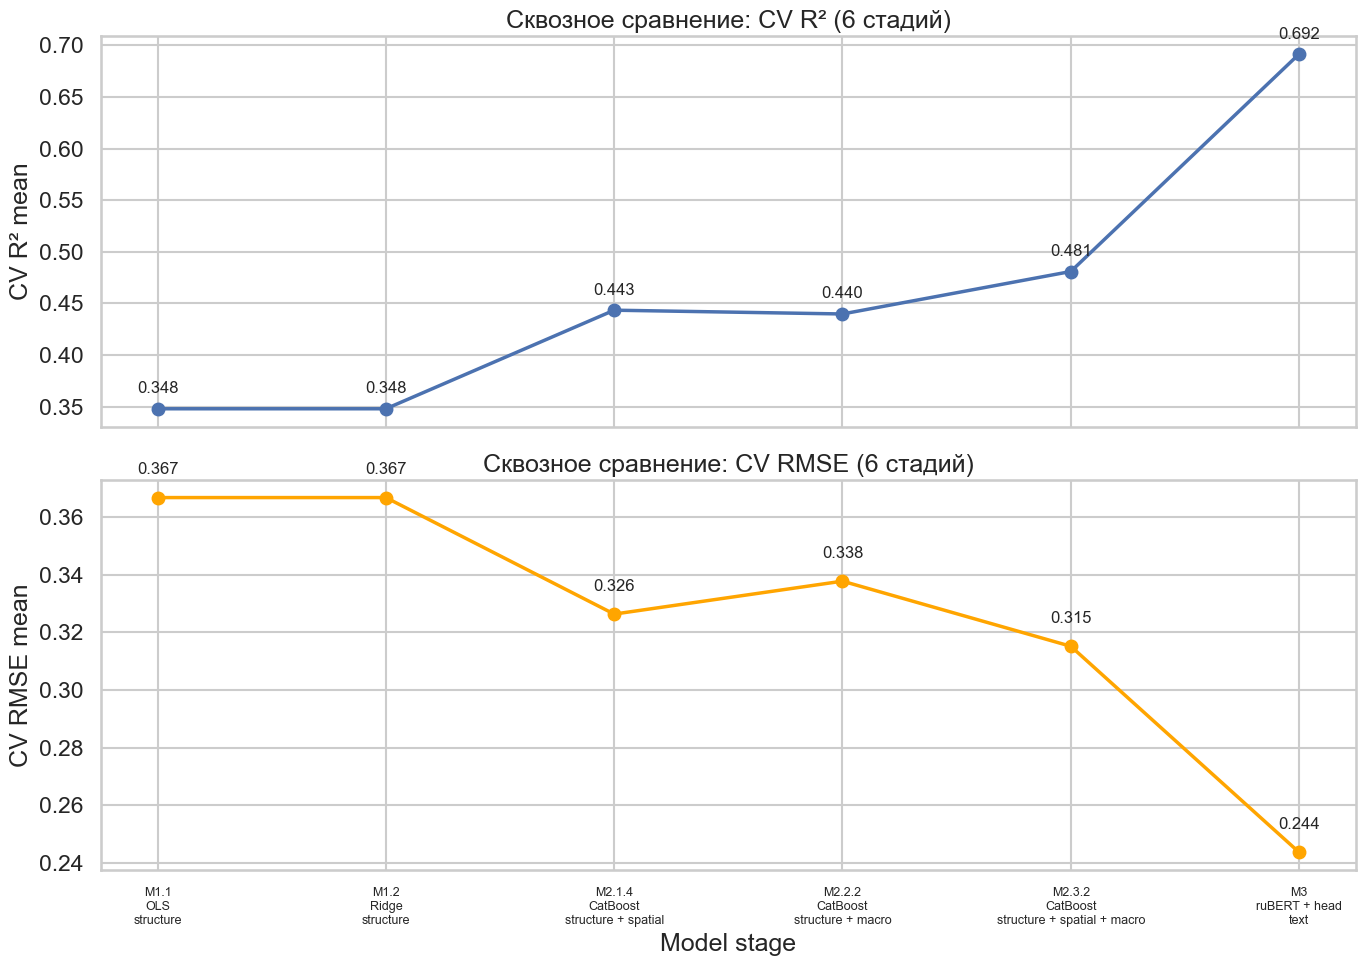

In [15]:
stage_order = ["M1.1", "M1.2", "M2.1.4", "M2.2.2", "M2.3.2", "M3"]
plot_df = final_results_all.copy()
plot_df = plot_df.set_index("Stage").loc[stage_order].reset_index()
stages = [
    f"{row.Stage}\n{row.Algorithm}\n{row.Features.lower()}"
    for row in plot_df.itertuples(index=False)
]
rmse = plot_df["CV_RMSE_mean"].tolist()
r2 = plot_df["CV_R2_mean"].tolist()
x = np.arange(len(stages))
sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(x, r2, marker="o", linewidth=2.5)
axes[0].set_title("Сквозное сравнение: CV R² (6 стадий)")
axes[0].set_ylabel("CV R² mean")
axes[0].set_xticks(x)
axes[0].set_xticklabels(stages, fontsize=9)
for i, v in enumerate(r2):
    axes[0].text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=12)
axes[1].plot(x, rmse, marker="o", linewidth=2.5, color="orange")
axes[1].set_title("Сквозное сравнение: CV RMSE (6 стадий)")
axes[1].set_xlabel("Model stage")
axes[1].set_ylabel("CV RMSE mean")
axes[1].set_xticks(x)
axes[1].set_xticklabels(stages, fontsize=9)
for i, v in enumerate(rmse):
    axes[1].text(i, v + 0.008, f"{v:.3f}", ha="center", fontsize=12)
plt.tight_layout()
plt.show()